# Bases, Dimension, and Coordinates

A computational companion to [Bases, Dimension, and Coordinates](https://fjhickernell.github.io/MATH332Fall2026/slides/07-bases-dimension-and-coordinates.html). Extract bases from generators and compare coordinate columns for the same vector or polynomial.

The deck supplies the mathematical exposition. Predict each result before running its cell; use exact SymPy calculations to check your reasoning. Numerical plots illustrate the examples rather than prove general statements.

## Running this notebook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/fjhickernell/MATH332Fall2026/blob/main/notebooks/demonstrations/07-bases-dimension-and-coordinates.ipynb)

Run all cells in order with the **qmcpy** kernel. The setup cell changes the environment only in Colab, where it installs the course's recorded `classlib` checkout. It leaves the working directory unchanged. Colab does not save edits to the course repository; save a copy in Drive to retain your experiments.

In [1]:
from pathlib import Path
import subprocess
import sys
import time

NOTEBOOK_START_TIME = time.perf_counter()

colab = "google.colab" in sys.modules
if colab:
    print("Setting up this course's recorded classlib; this may take a minute …")
    course_checkout = Path("/content/MATH332Fall2026")
    if not course_checkout.exists():
        subprocess.run(
            [
                "git", "clone", "--quiet", "--depth", "1",
                "https://github.com/fjhickernell/MATH332Fall2026.git",
                str(course_checkout),
            ],
            check=True,
        )
    subprocess.run(
        [
            "git", "-C", str(course_checkout),
            "-c", "submodule.classlib.url=https://github.com/fjhickernell/HickernellAcademicLib.git",
            "submodule", "update", "--init", "--recursive", "classlib",
        ],
        check=True,
    )
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", str(course_checkout / "classlib")],
        check=True,
    )
    print("Colab setup complete.")

In [2]:
import numpy as np
import sympy as sp
from sympy import Matrix
import matplotlib.pyplot as plt
import classlib as cl
from IPython.display import display, Markdown

%matplotlib inline
cl.nbviz.init(use_tex=False)
sp.init_printing()
np.set_printoptions(precision=5, suppress=True)
colors = [cl.nbviz.TOL_BRIGHT["blue"], cl.nbviz.TOL_BRIGHT["red"]]
t = sp.symbols("t", real=True)

def show(label, value):
    display(Markdown(label))
    display(value)


## 1. Extract a basis from a spanning list

Use the deck's generators of the plane $z=x+y$ as the columns of $\mathsf{V}$. Locate pivots with row reduction; take the basis columns from the original matrix. Python column indices start at zero.

Original generators V

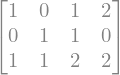

rref(V)

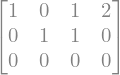

Pivot column numbers (one-based): [1, 2]


Basis columns from V

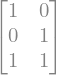

Coordinates of all four generators in the retained basis

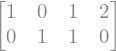

In [3]:
V = Matrix([[1,0,1,2], [0,1,1,0], [1,1,2,2]])
reduced, pivots = V.rref()
B = V[:, list(pivots)]
show("Original generators V", V)
show("rref(V)", reduced)
print("Pivot column numbers (one-based):", [j+1 for j in pivots])
show("Basis columns from V", B)
assert B.rank() == 2
assert V[:,2] == V[:,0]+V[:,1] and V[:,3] == 2*V[:,0]
show("Coordinates of all four generators in the retained basis", B.gauss_jordan_solve(V)[0])


### Another basis and a redundant list

Use the same vector $x=(3,1,4)^{\mathsf T}$ with two ordered bases of the plane. Check reconstruction in both. The original four-generator list is redundant: display its full family of coefficient lists.

Coordinates in (v1,v2)

Coordinates in (v2,v3)

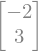

All representations using four generators

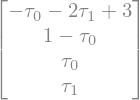

In [4]:
x = Matrix([3,1,4])
C = V[:, [1,2]]
x_B = B.gauss_jordan_solve(x)[0]
x_C = C.gauss_jordan_solve(x)[0]
show("Coordinates in (v1,v2)", x_B)
show("Coordinates in (v2,v3)", x_C)
assert B*x_B == x and C*x_C == x
show("All representations using four generators", V.gauss_jordan_solve(x)[0])
assert C.rank() == 2


## 2. Matrix vectors have coordinates too

In the space of symmetric $2\times2$ matrices, use the ordered basis consisting of the two diagonal matrix units and the symmetric off-diagonal matrix. Flattening below is only a computational representation, with entry order $(11,12,21,22)$.

Symmetric matrix

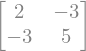

Coordinates in the stated matrix basis

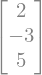

Dimension of this symmetric matrix space: 3


In [5]:
matrix_basis = (Matrix([[1,0],[0,0]]), Matrix([[0,1],[1,0]]), Matrix([[0,0],[0,1]]))
S = Matrix([[2,-3],[-3,5]])
flattened_basis = Matrix.hstack(*(Matrix(list(M)) for M in matrix_basis))
S_coordinates = flattened_basis.gauss_jordan_solve(Matrix(list(S)))[0]
reconstructed = sum((value*M for value,M in zip(S_coordinates,matrix_basis)), sp.zeros(2))
show("Symmetric matrix", S)
show("Coordinates in the stated matrix basis", S_coordinates)
assert reconstructed == S and flattened_basis.rank() == 3
print("Dimension of this symmetric matrix space: 3")


## 3. Polynomial coordinates and change of basis

Use the deck's ordered bases $\mathcal{B}=(1,1+t,t^2)$ and $\mathcal{C}=(1,t,t+t^2)$ of $\mathbb{P}_2$, and $p=2-3t+5t^2$. Coefficient columns below use the standard order $1,t,t^2$.

Coordinates in B

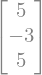

Coordinates in C

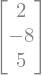

Transition matrix: input B-coordinates, output C-coordinates

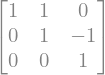

Each transition column reconstructs the corresponding B-polynomial in C.


In [6]:
def coefficients(poly):
    return Matrix([sp.expand(poly).coeff(t,j) for j in range(3)])

polynomial_B = (sp.Integer(1), 1+t, t**2)
polynomial_C = (sp.Integer(1), t, t+t**2)
P_B = Matrix.hstack(*(coefficients(poly) for poly in polynomial_B))
P_C = Matrix.hstack(*(coefficients(poly) for poly in polynomial_C))
p = 2-3*t+5*t**2
p_B = P_B.inv()*coefficients(p)
p_C = P_C.inv()*coefficients(p)
Q_C_from_B = P_C.inv()*P_B
show("Coordinates in B", p_B)
show("Coordinates in C", p_C)
show("Transition matrix: input B-coordinates, output C-coordinates", Q_C_from_B)
assert Q_C_from_B*p_B == p_C
assert p_B == Matrix([5,-3,5]) and p_C == Matrix([2,-8,5])
for j, poly in enumerate(polynomial_B):
    assert sp.expand(sum(Q_C_from_B[k,j]*polynomial_C[k] for k in range(3))-poly) == 0
print("Each transition column reconstructs the corresponding B-polynomial in C.")


### Coordinates change; the polynomial does not

Compare the two coefficient lists, then reconstruct the polynomial in each basis. The bars are coordinates, not values of the polynomial at three points.

Both reconstructions give

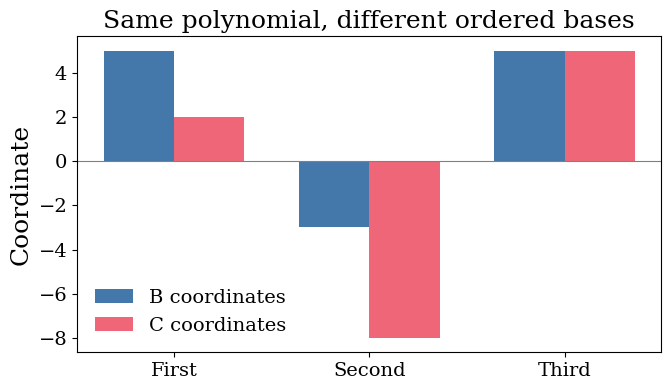

In [7]:
p_from_B = sp.expand(sum(value*poly for value,poly in zip(p_B,polynomial_B)))
p_from_C = sp.expand(sum(value*poly for value,poly in zip(p_C,polynomial_C)))
assert p_from_B == p_from_C == p
show("Both reconstructions give", p_from_B)
positions = np.arange(3)
fig, ax = plt.subplots(figsize=(7,4))
ax.bar(positions-0.18,np.array(p_B,dtype=float).ravel(),width=0.36,color=colors[0],label="B coordinates")
ax.bar(positions+0.18,np.array(p_C,dtype=float).ravel(),width=0.36,color=colors[1],label="C coordinates")
ax.axhline(0,color="gray",linewidth=0.8)
ax.set(xticks=positions,xticklabels=["First","Second","Third"],ylabel="Coordinate",title="Same polynomial, different ordered bases")
ax.legend()
plt.tight_layout()
plt.show()


## 4. Coordinate arithmetic

Keep $\mathcal{B}=(1,1+t,t^2)$. Start with $[p]_{\mathcal B}=(1,2,-1)^{\mathsf T}$ and $[q]_{\mathcal B}=(-2,1,3)^{\mathsf T}$. Compute $[p+2q]_{\mathcal B}$ first, then reconstruct. Why is the constant coefficient different from the first coordinate?

Coordinates of p+2q

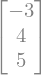

Reconstructed polynomial

In [8]:
u_B, v_B = Matrix([1,2,-1]), Matrix([-2,1,3])
combination_B = u_B+2*v_B
combination_poly = sp.expand(sum(value*poly for value,poly in zip(combination_B,polynomial_B)))
show("Coordinates of p+2q", combination_B)
show("Reconstructed polynomial", combination_poly)
assert combination_B == Matrix([-3,4,5])
assert combination_poly == 1+4*t+5*t**2


## Your experiments

1. Reorder the columns of the basis `B` in Section 1. Predict the change in coordinates, then verify reconstruction.
2. Try the pair $(v_1,v_4)$ as a basis of the plane. Explain the failure using dependence and dimension.
3. Reorder `polynomial_C` in Section 3. Compute the new transition matrix and check its direction by reconstruction.
4. Replace the third polynomial in `polynomial_B` by $1+2t$. Determine why it no longer defines a basis of $\mathbb{P}_2$.

Return to the deck for the distinction between spanning, independence, and basis. An ordered basis gives unique coordinates; a redundant spanning list does not.

In [9]:
notebook_elapsed = time.perf_counter() - NOTEBOOK_START_TIME
notebook_minutes, notebook_seconds = divmod(notebook_elapsed, 60)
print(
    "Total execution time for this notebook is "
    f"{int(notebook_minutes)} min {notebook_seconds:.1f} sec."
)

Total execution time for this notebook is 0 min 5.3 sec.
